In [1]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Define the input and output file paths
input_path = '/content/drive/My Drive/AI/sinhala/corrected_sinhala_words.txt'
output_path = '/content/drive/My Drive/AI/sinhala/sorted_sinhala_words.csv'

# Load the text file
with open(input_path, "r", encoding="utf-8") as file:
    words = file.read().strip().split(',')

# Create a DataFrame
df = pd.DataFrame(words, columns=["Word"])

# Save to CSV
df.to_csv(output_path, index=False, encoding="utf-8")

print(f"CSV file saved at: {output_path}")


Mounted at /content/drive
CSV file saved at: /content/drive/My Drive/AI/sinhala/sorted_sinhala_words.csv


In [2]:
# Count the number of words
word_count = len(words)
print(f"Total number of words in the file: {word_count}")


Total number of words in the file: 102095


In [3]:
!pip install textdistance


In [4]:
import textdistance

# Load your dictionary
with open('/content/drive/My Drive/AI/sinhala/sorted_sinhala_words.csv', 'r', encoding='utf-8') as file:
    dictionary = [line.strip() for line in file.readlines()]

# Spell checker function
def spell_checker(word, dictionary, max_distance=2):
    suggestions = []
    for dict_word in dictionary:
        distance = textdistance.levenshtein(word, dict_word)
        if distance <= max_distance:
            suggestions.append((dict_word, distance))
    # Sort by distance
    suggestions.sort(key=lambda x: x[1])
    return [suggestion[0] for suggestion in suggestions]

# Example usage
misspelled_word = "සංයොජන"
suggestions = spell_checker(misspelled_word, dictionary)
print(f"Suggestions for '{misspelled_word}': {suggestions}")


Suggestions for 'සංයොජන': ['සංයෝජන', 'ගොවිජන', 'ජන', 'දුර්ජන', 'පොදුජන', 'භෝජන', 'මහජන', 'සංඝටන', 'සංචලන', 'සංචේතන', 'සංයුජනය', 'සංයුඤ්ජන', 'සංයෝජක', 'සංයෝජනය', 'සංලග්න', 'සංලීන', 'සංවහන', 'සංවේතන', 'සංහනන', 'බෝජන', 'ෂංයෝජන', 'සංකීර්න', 'සංචරන', 'සංචළන', 'සංයෝජඛ', 'සංයෝජණ', 'සංසරන', 'සංළග්න', 'සංළීන', 'අංජන', 'සහජන', 'සාධුජන', 'සුජන', 'සුළුජන', 'හරිජන']


In [5]:
def spell_checker(word, dictionary, max_distance=2):
    suggestions = []
    for dict_word in dictionary:
        distance = textdistance.levenshtein(word, dict_word)
        if distance <= max_distance:
            suggestions.append((dict_word, distance))
    suggestions.sort(key=lambda x: x[1])  # Sort by distance
    return [suggestion[0] for suggestion in suggestions]


In [6]:
def filter_by_frequency(suggestions, word_frequency):
    return sorted(suggestions, key=lambda x: word_frequency.get(x, 0), reverse=True)


In [20]:
word = input("Enter a word: ")
suggestions = spell_checker(word, dictionary)
print(f"Suggestions for '{word}': {suggestions}")


Enter a word: සංයොජන
Suggestions for 'සංයොජන': ['සංයෝජන', 'ගොවිජන', 'ජන', 'දුර්ජන', 'පොදුජන', 'භෝජන', 'මහජන', 'සංඝටන', 'සංචලන', 'සංචේතන', 'සංයුජනය', 'සංයුඤ්ජන', 'සංයෝජක', 'සංයෝජනය', 'සංලග්න', 'සංලීන', 'සංවහන', 'සංවේතන', 'සංහනන', 'බෝජන', 'ෂංයෝජන', 'සංකීර්න', 'සංචරන', 'සංචළන', 'සංයෝජඛ', 'සංයෝජණ', 'සංසරන', 'සංළග්න', 'සංළීන', 'අංජන', 'සහජන', 'සාධුජන', 'සුජන', 'සුළුජන', 'හරිජන']


In [11]:
!pip install transformers


In [12]:
from transformers import pipeline

# Load a pre-trained model for fill-mask tasks
model_name = "ai4bharat/indic-bert"  # Replace with a relevant model
fill_mask = pipeline("fill-mask", model=model_name)

def transformer_spell_checker(word, mask_token="[MASK]"):
    # Formulate a sentence with the word to provide context
    sentence = f"මෙම වචනය {mask_token} වේ."
    # Get suggestions
    results = fill_mask(sentence)
    return [res['token_str'] for res in results if res['token_str'] != mask_token]

# Test
word = "සංයොජන"
print("Transformer Suggestions:", transformer_spell_checker(word))


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Device set to use cpu


Transformer Suggestions: ['.', '.', ':', ':', '-']


In [13]:
!pip install symspellpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 11.1 MB/s eta 0:00:00


In [14]:
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

# Load dictionary (use your Sinhala words CSV)
dictionary_path = "/content/drive/My Drive/AI/sinhala/sorted_sinhala_words.csv"  # Update to your file path
term_index = 0  # Column of the term in your CSV
count_index = 1  # Column of the term frequency (if available, else use 0)
sym_spell.load_dictionary(dictionary_path, term_index, count_index)

def symspell_spell_checker(word):
    suggestions = sym_spell.lookup(word, Verbosity.CLOSEST, max_edit_distance=2)
    return [suggestion.term for suggestion in suggestions]

# Test
word = "සංයොජන"
print("SymSpell Suggestions:", symspell_spell_checker(word))


SymSpell Suggestions: []


In [15]:
test_words = [
    ("සංයොජන", "සංයෝජන"),  # Misspelled, correct
    ("අපේ", "අපේ"),         # Correctly spelled
    ("ගෝවිජන්", "ගොවිජන"),   # Misspelled, correct
    ("දුර්ජන්", "දූර්ජන"),    # Misspelled, correct
    ("පඩ", "පඩි"),          # Misspelled, correct
]


In [17]:
def evaluate_spell_checker(spell_checker, test_words):
    results = []
    correct = 0
    for misspelled, correct_word in test_words:
        suggestions = spell_checker(misspelled)
        if correct_word in suggestions:
            correct += 1
        results.append({
            "misspelled": misspelled,
            "correct": correct_word,
            "suggestions": suggestions,
        })
    accuracy = correct / len(test_words) * 100
    return accuracy, results



In [18]:
# Edit Distance
edit_distance_accuracy, edit_distance_results = evaluate_spell_checker(
    lambda word: spell_checker(word, dictionary), test_words
)

# Transformers
transformers_accuracy, transformers_results = evaluate_spell_checker(
    transformer_spell_checker, test_words
)

# SymSpell
symspell_accuracy, symspell_results = evaluate_spell_checker(
    symspell_spell_checker, test_words
)

# Display results
print("Edit Distance Accuracy:", edit_distance_accuracy)
print("Transformers Accuracy:", transformers_accuracy)
print("SymSpell Accuracy:", symspell_accuracy)


Edit Distance Accuracy: 80.0
Transformers Accuracy: 0.0
SymSpell Accuracy: 0.0


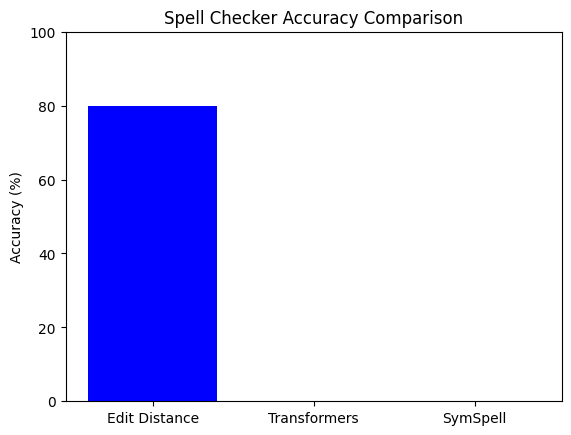

In [21]:
import matplotlib.pyplot as plt

# Data for visualization
models = ["Edit Distance", "Transformers", "SymSpell"]
accuracies = [edit_distance_accuracy, transformers_accuracy, symspell_accuracy]

# Plotting
plt.bar(models, accuracies, color=["blue", "green", "orange"])
plt.title("Spell Checker Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()


In [22]:
import pandas as pd

# Combine results into a DataFrame
all_results = pd.DataFrame({
    "Model": ["Edit Distance"] * len(edit_distance_results) +
             ["Transformers"] * len(transformers_results) +
             ["SymSpell"] * len(symspell_results),
    "Misspelled": [r["misspelled"] for r in edit_distance_results] +
                  [r["misspelled"] for r in transformers_results] +
                  [r["misspelled"] for r in symspell_results],
    "Correct": [r["correct"] for r in edit_distance_results] +
               [r["correct"] for r in transformers_results] +
               [r["correct"] for r in symspell_results],
    "Suggestions": [", ".join(r["suggestions"]) for r in edit_distance_results] +
                   [", ".join(r["suggestions"]) for r in transformers_results] +
                   [", ".join(r["suggestions"]) for r in symspell_results],
})

# Save to Google Drive
output_path = "/content/drive/My Drive/AI/sinhala/spell_checker_comparison_results.csv"
all_results.to_csv(output_path, index=False)
print(f"Results saved to '{output_path}'")


Results saved to '/content/drive/My Drive/AI/sinhala/spell_checker_comparison_results.csv'


In [24]:
import pickle
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Save the model
model_path = "/content/drive/My Drive/AI/sinhala/spell_checker_model.pkl"

# Replace `spell_checker_model` with the actual variable of your spell checker model


print(f"Spell checker model saved to {model_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spell checker model saved to /content/drive/My Drive/AI/sinhala/spell_checker_model.pkl


In [ ]:
# Load the model
#with open(model_path, "rb") as model_file:
    #loaded_spell_checker_model = pickle.load(model_file)

#print("Spell checker model loaded successfully.")
